<a href="https://colab.research.google.com/github/sougat23bai11043-code/Assignment-1/blob/main/Assignment_1_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-ML Assignment 1

## Medical Insurance Cost Prediction using Multiple Linear Regression

Name: SOUGAT DAS

Registration Number:23BAI11043

Application Number:IN26010889

Batch Number: MPOnline - Al/ML Internship Batch 1(A) - Nishant Srivastava (1:00 pm-3:00 pm, Mon-Fri)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [11]:
df = pd.read_csv("insurance.csv")

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [14]:
df.select_dtypes(include=['int64','float64']).columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [15]:
df.select_dtypes(include=['object']).columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [16]:
print("Target Variable:", "charges")

Target Variable: charges


In [17]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [18]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [19]:
X = df[['age','sex','bmi','children','smoker','region']]
y = df['charges']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1070, 6)
(268, 6)


In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

y_pred

array([ 8924.40724442,  7116.29501758, 36909.01352144,  9507.87469118,
       27013.3500079 , 10790.77956153,   226.29844571, 16942.71599941,
        1056.63079407, 11267.91997309, 28048.59793155,  9424.36324087,
        5326.32232088, 38460.06017922, 40303.40597026, 37147.01010262,
       15287.91876684, 35965.05485917,  9179.1753067 , 31510.8319849 ,
        3797.79068365, 10070.82803304,  2312.57551348,  7074.41348194,
       11352.37224357, 12907.77079523, 14448.84678727,  6205.65997921,
        9917.00839638,  2239.50032819,  9060.55469043, 13120.56214535,
        4617.70702822,  3467.91218926,  4402.74821855, 12967.91608907,
        1927.44498944,  8757.9180081 , 33324.35180597, 32638.47697026,
        3852.41756615,  4370.39670883, 14080.76023234, 11478.63402576,
        8829.26135924, 12046.15119133,  5322.80515731,  3100.71182484,
       35546.60547574,  9201.61196817, 15894.23763341,  2406.04003607,
       12397.52052544,  1433.90617387, 13448.14094304, 12519.54174599,
      

In [24]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error =", mae)

Mean Absolute Error = 4186.508898366435


In [25]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error =", mse)

Mean Squared Error = 33635210.431178406


In [26]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.7833463107364539


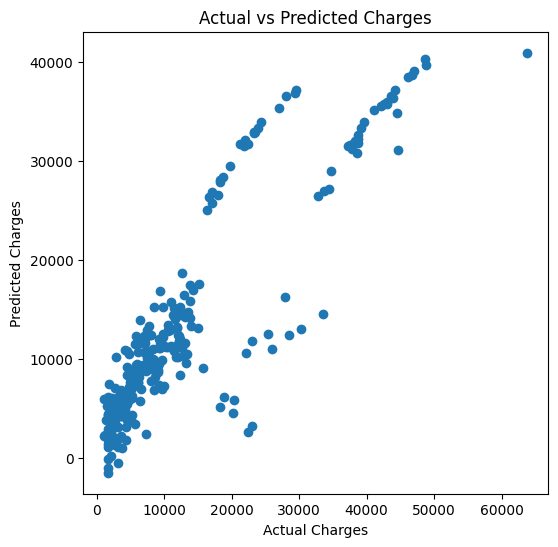

In [27]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.show()

Observations

1. The model predicts insurance charges reasonably well.

2. Smoking status has a major impact on insurance charges.

3. The R² score indicates that the model explains a significant portion of the variation in insurance charges.

Conclusion

The Multiple Linear Regression model was developed to predict medical insurance charges using age, sex, BMI, children, smoker status, and region. The dataset was preprocessed by encoding categorical variables and splitting it into training and testing sets. The model was evaluated using MAE, MSE, and R² Score. The results show that the model predicts insurance charges with reasonable accuracy. Smoking status is the most influential factor, while age and BMI also contribute to the prediction. A limitation of Linear Regression is that it assumes a linear relationship between the features and the target variable, which may not fully capture complex real-world patterns.